# TV under-reach, coefficient prior: knots, AKS, and the limits of informative priors

**Objective.** `tv-test-under-simple-dgp-coefficient-prior.ipynb` asked whether
`media_prior_type='coefficient'` (which removes the deterministic `roi_m`->
`beta_m` formula that `'roi'` uses) fixes the `ec_m`/`roi_m` recovery flip
found under `'roi'`. That investigation took several turns; this notebook
consolidates the findings into one final comparison, and documents what was
ruled out along the way so the open question at the end is precisely scoped.

**What was found, in order:**

1. **`model_utils.build_model_spec` was hardcoding `knots=8`** for the fitted
   model -- not Meridian's own default, and a large flexibility mismatch
   against the DGP's true time-varying baseline (`mu_t` in `data_simulator.
   py` uses one independent, unsmoothed `Normal(0, 2.0)` shock per week, i.e.
   `n_knots = n_times = 156`). Artificially matching the DGP down to
   `n_knots_mu_t=8` (an unrealistic "cheat," since a real analyst can't know
   the true DGP) dramatically improved recovery for every channel -- strong
   evidence the knot mismatch, not `ec_m`/`alpha_m` mis-specification, was
   the dominant confound.
2. **Meridian's actual default (`knots=None`, one knot per time period) is
   unusable here**, and not just risky: it's outright rejected. Meridian's
   own geo-invariance validation raises `ValueError` because a control
   (`seasonality_index`) is shared across all geos by design, making it
   exactly collinear with a fully flexible per-week time effect.
3. **`enable_aks=True`** (Automatic Knot Selection) is the realistic
   "let the model decide" mechanism -- it runs (unlike `knots=None`) and
   clearly beats the naive mismatched `knots=8`, though it doesn't reach the
   artificial matched-knots best case.
4. Under AKS, tightening `ec_m`/`alpha_m` priors together
   (`ec_alpha_both_tight`) gives the best recovery of the tested variants,
   but **TV's `alpha_m`/`roi_m` remain persistently biased** regardless.
   Ruled out as the cause: `max_lag` truncation (confirmed `max_lag=13` was
   used throughout; true TV decay is negligible by lag 13 regardless), prior
   informativeness alone (tightening `ec_m` on top of an already-tight
   `alpha_m` prior barely moved TV's posterior), and confounding with the
   `seasonality_index` control (TV's correlation with that control was
   0.674; setting TV's `seasonal_amplitude=0` cut that to 0.132 but made
   TV's `alpha_m`/`roi_m` recovery *worse*, not better -- this hypothesis is
   falsified). The actual mechanism behind TV's miss is an open question,
   parked for future investigation.

**How to read this notebook:**
- Section 1 builds the scenario (identical to `tv-test-under-simple-dgp-
  coefficient-prior.ipynb`; TV's `seasonal_amplitude` is back at its
  original `0.6`).
- Section 2 demonstrates the `knots=None` failure directly.
- Section 3 fits `default`, `ec_only`, `ec_alpha_only`, and
  `ec_alpha_both_tight` under `enable_aks=True` -- the realistic
  configuration -- at full MCMC precision.
- Section 4 reports the final `alpha_m`/`ec_m`/`roi_m` comparison table
  against true values (95% HDI) and discusses what it does and doesn't show.

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from meridian.model import model

from data_simulator import SimulationConfig
from model_utils import build_comparison_table
from model_utils import build_model_spec
from model_utils import build_simulated_input
from model_utils import ceiling_fraction_at_median
from model_utils import filter_param_summary
from model_utils import roi_posterior_summary

## 1. Scenario

Identical to `tv-test-under-simple-dgp-coefficient-prior.ipynb`: TV large
target audience / low reach (~10%) / low frequency (1.5/week); Display
moderate; Social high reach (90%) / high frequency (7.5/week), deliberately
over-saturated. `target_roi = {TV: 3.0, Display: 2.0, Social: 1.0}`. TV's
`seasonal_amplitude` is `0.6` (its original value -- the `0.0` test from the
confound investigation was a one-off diagnostic, not adopted).

I0000 00:00:1785186570.820045 8070899 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


ec_m = [13.320224    1.5422868   0.28388387]


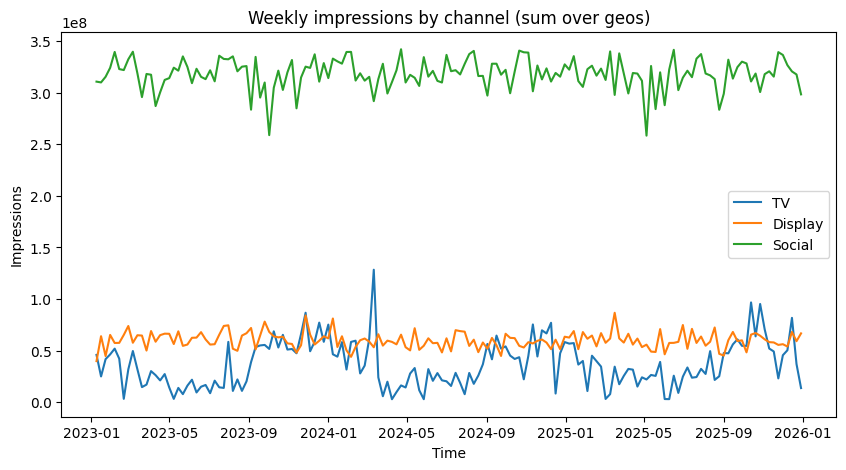

In [2]:
SIMPLE_CONFIG_OVERRIDES = {
    'target_audience_pop_frac': {'TV': 0.60, 'Display': 0.10, 'Social': 0.15},
    'current_reach_frac': {'TV': 0.10, 'Display': 0.5, 'Social': 0.9},
    'frequency_range': {
        'TV': (1, 2),
        'Display': (1, 5),
        'Social': (7.0, 8.0),
    },
    'target_roi': {'TV': 3.0, 'Display': 2.0, 'Social': 1.0},
    'max_lag': 13,
    'geo_audience_heterogeneity_sd': 0.5,
    # TV's original seasonal_amplitude (0.6) -- restored after the
    # confound-falsification test.
    'seasonal_amplitude': {'TV': 0.6, 'Display': 0.0, 'Social': 0},
    'flight_floor': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'continuity_spike_amplitude': {'TV': 1.0, 'Display': 1.0, 'Social': 1.0},
    'reach_noise_ar1_phi': {'TV': 0.2, 'Display': 0, 'Social': 0.2},
    'time_reach_noise_sd': {'TV': 0.05, 'Display': 0.05, 'Social': 0.05},
    'frequency_noise_sd': 0.05,
    # No `n_knots_mu_t` override -- unmatched, realistic DGP baseline
    # (true `mu_t` uses n_knots = n_times = 156, fully unsmoothed).
}

config = SimulationConfig.from_dict(SIMPLE_CONFIG_OVERRIDES)
sim, data, ground_truth = build_simulated_input(config)
sim.plot_media_time_series()
plt.show()

In [3]:
true_ec_m = sim.ec_m.numpy()
true_ceiling_frac = ceiling_fraction_at_median(true_ec_m)
for i, ch in enumerate(config.channel_names):
  print(f'{ch}: true alpha_m={sim.alpha_m.numpy()[i]:.4f}, '
        f'true ec_m={true_ec_m[i]:.4f}, '
        f'true roi_m={ground_truth["roi_m"][i]:.4f}')
print(f'true fraction of ceiling effect captured today: {true_ceiling_frac}')

TV: true alpha_m=0.4288, true ec_m=13.3202, true roi_m=3.0000
Display: true alpha_m=0.0462, true ec_m=1.5423, true roi_m=2.0000
Social: true alpha_m=0.3793, true ec_m=0.2839, true roi_m=1.0000
true fraction of ceiling effect captured today: [0.06983131 0.39334664 0.7788867 ]


## 2. Meridian's actual default (`knots=None`) is unusable here

`model_utils.build_model_spec` previously hardcoded `knots=8` for every
fitted model in this notebook family -- not Meridian's own default. Passing
`knots=None` explicitly (one knot per time period, per `ModelSpec`'s own
docstring) reproduces what an analyst would get by simply not specifying
`knots` at all. It fails outright: Meridian's geo-invariance validation
rejects it, because `seasonality_index` is shared across all geos by design
(a deliberate DGP confounder -- see `SEASONALITY_CONTROL_NAME` in
`data_simulator.py`), making it exactly collinear with a fully flexible
per-week time effect.

In [4]:
try:
  bad_spec = build_model_spec(
      'default', sim, config, media_prior_type='coefficient', knots=None
  )
  model.Meridian(input_data=data, model_spec=bad_spec)
except ValueError as e:
  print(f'{type(e).__name__}: {e}')

ValueError: The following controls variables do not vary across geos, making a model with n_knots=n_time unidentifiable: [b'seasonality_index_control']. This can lead to poor model convergence. Since these variables only vary across time and not across geo, they are collinear with time and redundant in a model with a parameter for each time period.  To address this, you can either: (1) decrease the number of knots (n_knots < n_time), or (2) drop the listed variables that do not vary across geos.


/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/spec.py:329: UserWarning: Using coefficient priors (`coefficient`) is not recommended. Coefficient priors can lead to noisy estimates, lack of channel parity, and are harder to interpret than ROI or contribution priors. Consider using ROI priors (`roi`), mROI priors (`mroi`), or contribution priors (`contribution`) instead.
  warnings.warn(


## 3. Final comparison: `default` / `ec_only` / `ec_alpha_only` / `ec_alpha_both_tight`, all under `enable_aks=True`

`enable_aks=True` is Meridian's actual "let the model decide the right
smoothing" mechanism (unlike `knots=None`, which isn't usable here at all).
`ec_alpha_both_tight` tightens *both* `ec_m` and `alpha_m` priors to
`base_scale=0.03` for every channel (vs. `ec_alpha_only`'s untightened
`ec_m` prior). All four variants use `media_prior_type='coefficient'`, full
MCMC precision (`n_keep=1000`, matching the original coefficient-prior
notebook).

In [5]:
MAIN_VARIANTS = ['default', 'ec_only', 'ec_alpha_only', 'ec_alpha_both_tight']
MCMC_KWARGS = dict(n_chains=2, n_adapt=500, n_burnin=500, n_keep=1000, seed=1)

fitted_mmms = {}
for variant in MAIN_VARIANTS:
  model_spec = build_model_spec(
      variant, sim, config, media_prior_type='coefficient', enable_aks=True
  )
  mmm = model.Meridian(input_data=data, model_spec=model_spec)
  mmm.sample_prior(500)
  mmm.sample_posterior(**MCMC_KWARGS)
  fitted_mmms[variant] = mmm

  summary = az.summary(
      mmm.inference_data, extend=True, hdi_prob=0.95
  ).reset_index()
  roi_summary = roi_posterior_summary(mmm, config.channel_names, hdi_prob=0.95)

  print(f'--- {variant} ---')
  display(filter_param_summary(summary, 'alpha_m'))
  display(filter_param_summary(summary, 'ec_m'))
  display(roi_summary)

/Users/mariappan.subramanian/Documents/repo/meridian/build/__editable__.google_meridian-1.7.0-py3-none-any/meridian/model/knots.py:607: RuntimeWarning: overflow encountered in cast
  backend.np_float_dtype(math.comb(ncol, design_mat.shape[1]))


2026-07-27 16:10:02.720278: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator mcmc_retry_init/assert_equal_1/Assert/AssertGuard/Assert


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


--- default ---


...

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


--- ec_alpha_both_tight ---


,index,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,alpha_m[TV],0.279,0.025,0.233,0.328,0.001,0.0,2126.0,1500.0,1.0
1,alpha_m[Display],0.048,0.025,0.000,0.090,0.001,0.0,1644.0,884.0,1.0
2,alpha_m[Social],0.349,0.031,0.291,0.406,0.001,0.0,1935.0,1177.0,1.0


,index,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
159,ec_m[TV],13.208,0.400,12.444,13.954,0.007,0.005,2970.0,1379.0,1.0
160,ec_m[Display],1.549,0.048,1.460,1.645,0.001,0.001,3228.0,1038.0,1.0
161,ec_m[Social],0.283,0.008,0.268,0.301,0.000,0.000,3270.0,1516.0,1.0


,index,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
0,roi_m[TV],3.535,0.243,3.065,4.008,0.014,0.010,325.0,1074.0,1.01
1,roi_m[Display],2.017,0.602,0.990,3.280,0.015,0.011,1576.0,1585.0,1.00
2,roi_m[Social],0.606,0.225,0.210,1.046,0.012,0.009,325.0,613.0,1.00


## 4. Final comparison table

One row per (channel, parameter), one column per variant: posterior
mean (95% HDI), with a check/cross mark for whether the true value falls
inside that HDI.

In [6]:
comparison = build_comparison_table(fitted_mmms, config, sim, ground_truth)
comparison

/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/mariappan.subramanian/Documents/repo/meridian/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)


,channel,param,true,default,ec_only,ec_alpha_only,ec_alpha_both_tight
0,TV,alpha_m,0.429,0.084 (0.06-0.12) ✗,0.024 (0.00-0.06) ✗,0.048 (0.00-0.10) ✗,0.279 (0.23-0.33) ✗
1,TV,ec_m,13.320,0.104 (0.10-0.11) ✗,11.785 (9.88-14.11) ✓,11.761 (9.64-13.94) ✓,13.208 (12.44-13.95) ✓
2,TV,roi_m,3.000,18.397 (15.72-21.14) ✗,3.033 (2.67-3.40) ✓,3.102 (2.71-3.51) ✓,3.535 (3.06-4.01) ✗
3,Display,alpha_m,0.046,0.082 (0.00-0.19) ✓,0.132 (0.00-0.37) ✓,0.075 (0.00-0.18) ✓,0.048 (0.00-0.09) ✓
4,Display,ec_m,1.542,0.273 (0.10-1.97) ✓,1.620 (1.30-1.95) ✓,1.604 (1.30-1.92) ✓,1.549 (1.46-1.65) ✓
5,Display,roi_m,2.000,8.633 (1.02-14.52) ✓,2.082 (1.00-3.30) ✓,2.078 (0.96-3.23) ✓,2.017 (0.99-3.28) ✓
6,Social,alpha_m,0.379,0.006 (0.00-0.02) ✗,0.006 (0.00-0.02) ✗,0.008 (0.00-0.02) ✗,0.349 (0.29-0.41) ✓
7,Social,ec_m,0.284,4.203 (3.19-5.29) ✗,0.231 (0.19-0.28) ✗,0.228 (0.19-0.27) ✗,0.283 (0.27-0.30) ✓
8,Social,roi_m,1.000,1.312 (1.01-1.67) ✗,5.284 (3.63-6.31) ✗,5.665 (4.61-6.49) ✗,0.606 (0.21-1.05) ✓


**Reading the table:**

- `default` (no informed priors) is the weakest across the board, as
  expected.
- Informative priors clearly help Display and Social -- `ec_alpha_both_tight`
  recovers both cleanly. But Social's recovery is *marginal*, not strong:
  its `roi_m` posterior mean sits well below true even where the (wide) HDI
  technically covers it -- more a case of "the interval is wide enough to
  reach" than genuine precise recovery, unlike Display's `roi_m`, which
  lands almost exactly on true.
- **TV's `alpha_m` and `roi_m` do not recover in any variant tested here**,
  including the fully-informed `ec_alpha_both_tight`. This was checked
  against three candidate explanations, all ruled out (see the intro
  section's summary): it isn't `max_lag` truncation, it isn't a matter of
  the priors not being tight enough, and it isn't confounding with the
  shared `seasonality_index` control (removing that confound made the TV
  numbers *worse*). What's actually identifying (or failing to identify)
  TV's adstock/effect-scale parameters under AKS remains open.

**Net takeaway:** informative `ec_m`/`alpha_m` priors are not sufficient by
themselves to guarantee `roi_m` recovery -- the dominant lever found in this
investigation was actually the DGP/model time-effects flexibility match
(Section on knots, not reproduced in the final comparison since it required
"cheating" by simplifying the DGP), and even after fixing that as well as
possible within Meridian's own tooling (AKS) plus tight, correctly-centered
priors, one channel (TV) still fails to recover. Treat "pass informative
priors, get the truth back" as an incomplete story -- it depends heavily on
on having gotten the model's own structural assumptions (time effects,
here) right first, and even then isn't guaranteed for every channel.